# NIM Inference Benchmarking: Nemotron Across Three Industries

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/itsChanelML/nim-inference-benchmarking/blob/main/nim_benchmarking.ipynb)

**Author:** Chanel Power | [@itsChanelML](https://github.com/itsChanelML)  
**Model:** `nvidia/llama-3.3-nemotron-super-49b-v1.5` via NVIDIA NIM  
**Purpose:** Characterize NIM inference behavior across 3 industries to answer: *which model, which config, for which workload?*

## Test Matrix

| Industry | Tasks | Context Lengths | Tests |
|----------|-------|-----------------|-------|
| Climate Tech | Sensor summary, Policy brief, Risk assessment | Short/Medium/Long | 9 |
| Agriculture | Crop recommendation, Yield prediction, Soil analysis | Short/Medium/Long | 9 |
| Workforce Dev | Career advice, Skill gap, Job match scoring | Short/Medium/Long | 9 |
| **Total** | | | **27** |

In [ ]:
# Cell 0: Load Real Government Data
# Sources: NYC Open Data (DOHMH), USDA NASS API, BLS OES 2023, US Census ACS 2022

import sys
sys.path.insert(0, '.')

from load_data import load_all_data
from build_real_prompts import build_prompts

data = load_all_data()
PROMPTS = build_prompts(data)

print(f'Real data loaded. {len(PROMPTS)} prompts ready.')
print(f'Sources: NYC DOHMH Air Quality | USDA NASS | BLS OES 2023 | Census ACS 2022')

## Cell 1: Setup

In [1]:
import os
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from dotenv import load_dotenv
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

client = OpenAI(
    base_url='https://integrate.api.nvidia.com/v1',
    api_key=os.getenv('NVIDIA_API_KEY')
)

MODEL = 'nvidia/llama-3.3-nemotron-super-49b-v1.5'
COLORS = {'Climate Tech': '#2ECC71', 'Agriculture': '#F39C12', 'Workforce Dev': '#3498DB'}

print(f'Model: {MODEL}')
print(f'API Key: {"YES" if os.getenv("NVIDIA_API_KEY") else "NO — check .env"}')
print(f'Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Model: nvidia/llama-3.3-nemotron-super-49b-v1.5
API Key: YES
Started: 2026-04-18 13:44:14


## Cell 2: Prompts

In [2]:
PROMPTS = [
    {'industry': 'Climate Tech', 'task': 'Sensor Summary', 'context_length': 'Short',
     'prompt': 'Air quality data, Brooklyn NYC: PM2.5 18.3 ug/m3, CO2 412 ppm, Temp 62F. Summarize for community board.'},
    {'industry': 'Climate Tech', 'task': 'Sensor Summary', 'context_length': 'Medium',
     'prompt': 'Brooklyn air quality (3 stations): Downtown PM2.5 18.3, NO2 28ppb. Red Hook PM2.5 22.7, NO2 35ppb (near industrial waterfront). Flatbush PM2.5 14.1, NO2 21ppb. EPA: PM2.5 moderate 12-35. Summarize for community board, note concerns.'},
    {'industry': 'Climate Tech', 'task': 'Sensor Summary', 'context_length': 'Long',
     'prompt': 'Brooklyn air quality (4 stations): Downtown AQI 63. Red Hook AQI 74 (2.3x citywide asthma rate). Flatbush AQI 52. Sunset Park AQI 81 (PS 172 school 0.3 miles away). Historical: 30-day avg PM2.5 16.2. Summarize for community board, identify highest-risk neighborhoods, recommend 3 actions.'},
    {'industry': 'Climate Tech', 'task': 'Policy Brief', 'context_length': 'Short',
     'prompt': 'NYC committed to 80% carbon reduction by 2050. Write 3-sentence policy brief on building electrification.'},
    {'industry': 'Climate Tech', 'task': 'Policy Brief', 'context_length': 'Medium',
     'prompt': 'NYC: Buildings = 70% of GHG. Local Law 97 requires 40% cuts by 2030. Only 34% compliant. Heat pumps up 18% YoY. ConEd offers $10K incentive. Write 150-word policy brief on accelerating electrification with one recommendation.'},
    {'industry': 'Climate Tech', 'task': 'Policy Brief', 'context_length': 'Long',
     'prompt': 'NYC electrification data: 50K buildings under LL97, 34% compliant. Bronx 28%, Brooklyn 31% (lowest compliance + highest emissions). Contractor gap: 2,400 installers now, need 8,000+ by 2030. 62% cite upfront cost as barrier. IRA 30% credit + ConEd $10K incentive available. Write 250-word policy brief covering financing gap, workforce pipeline, environmental justice. Include 3 recommendations with impact estimates.'},
    {'industry': 'Climate Tech', 'task': 'Risk Assessment', 'context_length': 'Short',
     'prompt': 'Coastal NYC neighborhood, 15% flood risk by 2050. Write 2-sentence resident risk summary.'},
    {'industry': 'Climate Tech', 'task': 'Risk Assessment', 'context_length': 'Medium',
     'prompt': 'Red Hook Brooklyn: FEMA Zone AE, sea level +2.5ft by 2050, 15% annual 4ft surge probability. Sandy 2012: 6.9ft surge, $200M damage. 11K residents, 35% below poverty, 28% elderly/disabled. Write honest but actionable 150-word risk assessment.'},
    {'industry': 'Climate Tech', 'task': 'Risk Assessment', 'context_length': 'Long',
     'prompt': 'Red Hook comprehensive risk: Sea level +1.5ft by 2030, +2.5ft by 2050. 10% annual 3ft surge probability. NYCHA Red Hook Houses: 6,000 residents, buildings 60 years old. 2 evacuation routes both flood at 4ft. 35% poverty, 18% elderly, 34% car ownership. Write 300-word assessment for community leaders covering timeline, infrastructure, population risks, and 4 resilience investments by priority.'},
    {'industry': 'Agriculture', 'task': 'Crop Recommendation', 'context_length': 'Short',
     'prompt': 'Iowa corn, V6 stage, soil moisture 35%, temp 68F. What should farmer do this week?'},
    {'industry': 'Agriculture', 'task': 'Crop Recommendation', 'context_length': 'Medium',
     'prompt': 'Iowa corn V6 (Pioneer P1185AM): soil moisture 35% (FC 42%), soil temp 58F, 1.2in rain last 14 days (below avg), dry forecast 7 days. Pre-plant: 120 lbs/acre urea. Observed: lower leaf yellowing on 15% of plants. Recommendations for this week, address yellowing.'},
    {'industry': 'Agriculture', 'task': 'Crop Recommendation', 'context_length': 'Long',
     'prompt': '240-acre Iowa corn V6 (P1185AM): Zone 1 (140ac) moisture 35%, Zone 2 (60ac) 38%, Zone 3 (40ac) 29% — below threshold. N tissue test 3.6% (marginal, threshold 4.0%). 15% yellowing concentrated in Zone 3. Rainfall 1.2in last 14 days (avg 2.1). Dry 10 days then rain April 28-30. Cutworm 3 moths/trap (threshold 5). Provide 14-day plan with N rates by zone and Zone 3 irrigation guidance.'},
    {'industry': 'Agriculture', 'task': 'Yield Prediction', 'context_length': 'Short',
     'prompt': 'Iowa corn, V6 stage, normal rainfall, adequate fertility. Estimated yield range?'},
    {'industry': 'Agriculture', 'task': 'Yield Prediction', 'context_length': 'Medium',
     'prompt': 'Iowa corn 240 acres, Pioneer P1185AM, V6. Soil moisture slightly below FC in one zone. N tissue 3.6% (marginal). Rainfall 1.2in last 14 days. 5-year avg: 198 bu/ac. County avg: 187. Yield estimate range and top 2 factors?'},
    {'industry': 'Agriculture', 'task': 'Yield Prediction', 'context_length': 'Long',
     'prompt': 'Yield forecast request: Iowa corn P1185AM, 240 acres. N marginal, Zone 3 moisture low, no irrigation. 5-yr avg 198, best 224 (2021), worst 171 (2022 drought). Scenarios: A favorable (40%), B moderate stress (35%), C drought (25%). Side-dress 60 lbs N planned April 28. Corn futures $4.85/bu. Forecast by scenario with revenue impact. Identify single highest-impact management action.'},
    {'industry': 'Agriculture', 'task': 'Soil Analysis', 'context_length': 'Short',
     'prompt': 'Soil test: pH 5.8, P 18ppm, K 145ppm, OM 3.2%. Planting soybeans. Amendments needed?'},
    {'industry': 'Agriculture', 'task': 'Soil Analysis', 'context_length': 'Medium',
     'prompt': 'Iowa soil test (soybean field): pH 5.8 (target 6.2-6.8), P 18ppm (low, target 25-40), K 145ppm (adequate), OM 3.2%, Zn 0.8ppm (marginal). Spring 2026 soybeans. Amendment recommendations with specific rates per acre.'},
    {'industry': 'Agriculture', 'task': 'Soil Analysis', 'context_length': 'Long',
     'prompt': '160-acre Iowa soybean field (prev: corn 198 bu): pH 5.8, buffer pH 6.6, P 18ppm (low), K adequate, Zn 0.8ppm (marginal). Haney score 6.2/10. Compaction 280-320 psi at 12-16in depth in 40% of field (threshold 300 psi). Soybean $9.85/bu, lime $32/ton, DAP $620/ton. Complete amendment plan with ROI calculation per amendment, prioritized by yield impact.'},
    {'industry': 'Workforce Dev', 'task': 'Career Path Advice', 'context_length': 'Short',
     'prompt': 'First-generation professional, 2 years UX Research experience, trying to break into tech. Next career move?'},
    {'industry': 'Workforce Dev', 'task': 'Career Path Advice', 'context_length': 'Medium',
     'prompt': 'First-gen professional. MS communication design. UX Researcher at nonprofit 2 years ($72K). Skills: user interviews, usability testing, Figma basic. No CS degree, limited tech network, NYC. Target: tech company UXR role, $110K+, 12-18 months. Provide 3-step transition plan with concrete actions.'},
    {'industry': 'Workforce Dev', 'task': 'Career Path Advice', 'context_length': 'Long',
     'prompt': 'Career transition: MS Communication Design, City College. UX Researcher nonprofit 2 years ($72K). First-gen graduate. Skills: interviews 4/5, usability 3/5, surveys 4/5, data analysis 2/5, Figma 2/5, SQL 1/5. 3 case studies, 45 LinkedIn connections (3 in tech). Target: Spotify/Duolingo/Khan Academy/Etsy UXR, $115K-$130K, 18 months. Cannot leave job or take unpaid work. 18-month roadmap in 3 phases. Address no-CS-degree barrier directly.'},
    {'industry': 'Workforce Dev', 'task': 'Skill Gap Analysis', 'context_length': 'Short',
     'prompt': 'Current: Python basics, Excel, project management. Target: Data Analyst. Missing skills?'},
    {'industry': 'Workforce Dev', 'task': 'Skill Gap Analysis', 'context_length': 'Medium',
     'prompt': 'Candidate: Python (pandas), Excel (pivot tables), SQL (SELECT basics), PMP. 3 years operations analyst. Target: Data Analyst tech company $95K-$110K. Jobs require: advanced SQL, Python statistical analysis, Tableau or Power BI, A/B testing. Top 3 gaps with learning plan (resource + time to proficiency).'},
    {'industry': 'Workforce Dev', 'task': 'Skill Gap Analysis', 'context_length': 'Long',
     'prompt': 'Ops to Data Analyst: Python intermediate (no ML), SQL intermediate (no window functions), Excel advanced, Tableau viewer. 47 NYC job postings analyzed: 90%+ need advanced SQL and Tableau builder. 70%+ need Python stats and hypothesis testing. 8-10 hrs/week available, $100/month budget, 9-month timeline. Prioritized skill gap analysis with free/low-cost resources and one portfolio project demonstrating multiple skills.'},
    {'industry': 'Workforce Dev', 'task': 'Job Match Scoring', 'context_length': 'Short',
     'prompt': 'Candidate: 3 years data analysis, Python, SQL, Tableau. Job: 5 years required, advanced SQL, Python ML. Match score and gaps?'},
    {'industry': 'Workforce Dev', 'task': 'Job Match Scoring', 'context_length': 'Medium',
     'prompt': 'CANDIDATE: 3yr data analysis, Python intermediate, SQL intermediate, Tableau proficient, PMP, logistics domain.\nJOB: Senior Data Analyst Spotify NYC ($115K-$135K). Required: 5+ yrs, advanced SQL, Python stats, consumer analytics, Looker/Tableau.\nMatch score 0-100, top 3 gaps, apply now or not?'},
    {'industry': 'Workforce Dev', 'task': 'Job Match Scoring', 'context_length': 'Long',
     'prompt': 'CANDIDATE: 3yr ops analyst (logistics). Python intermediate, SQL intermediate (no window functions), Tableau proficient, Excel advanced, PMP, Google Data Analytics cert. 2 GitHub projects.\nJOB: Senior Data Analyst Growth, Etsy NYC ($110K-$130K). Required: 4+ yrs, expert SQL, Python proficiency, A/B testing, large datasets. Preferred: e-commerce, dbt/Looker, statistical modeling.\nProvide: match score by category, top 3 strengths, top 3 disqualifying gaps, apply now vs 6 months, cover letter opening addressing experience gap.'},
]
print(f'Prompts loaded: {len(PROMPTS)}')
print(f'Industries: {set(p["industry"] for p in PROMPTS)}')

Prompts loaded: 27
Industries: {'Agriculture', 'Climate Tech', 'Workforce Dev'}


## Cell 3: Quality Scoring

In [3]:
def score_output(output, prompt):
    output_lower = output.lower()
    key_terms = [w for w in prompt.lower().split()[:15] if len(w) > 4]
    relevance = min(5, max(1, int(sum(1 for t in key_terms if t in output_lower) / 2)))
    ratio = len(output.split()) / max(len(prompt.split()), 1)
    completeness = min(5, max(1, int(ratio / 0.4)))
    has_numbers = any(c.isdigit() for c in output)
    unique_words = len(set(output_lower.split()))
    specificity = min(5, max(2, 3 + (1 if has_numbers else 0) + (1 if unique_words > 80 else 0)))
    action_words = ['should','recommend','apply','consider','increase','decrease','monitor','implement','prioritize','focus']
    actionability = min(5, max(1, 2 + sum(1 for w in action_words if w in output_lower)))
    total = relevance + completeness + specificity + actionability
    return {'relevance': relevance, 'completeness': completeness, 'specificity': specificity,
            'actionability': actionability, 'total': total, 'normalized': round(total / 20 * 100, 1)}

print('Scoring rubric: Relevance + Completeness + Specificity + Actionability')
print('Scale: 1-5 each, 20 total, normalized to 100')

Scoring rubric: Relevance + Completeness + Specificity + Actionability
Scale: 1-5 each, 20 total, normalized to 100


## Cell 4: Run 27 Tests

In [4]:
results = []
total = len(PROMPTS)
print(f'Starting: {datetime.now().strftime("%H:%M:%S")}')
print(f'Running {total} tests...')
print('=' * 60)

for i, test in enumerate(PROMPTS):
    industry = test['industry']
    task = test['task']
    context_length = test['context_length']
    prompt = test['prompt']
    print(f'\nTest {i+1}/{total}: {industry} | {task} | {context_length}')
    try:
        start_time = time.time()
        response = client.chat.completions.create(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': f'You are an expert {industry} advisor. Be accurate, practical, specific.'},
                {'role': 'user', 'content': prompt}
            ],
            temperature=0.3,
            max_tokens=1200
        )
        latency = round(time.time() - start_time, 2)
        msg = response.choices[0].message
        output = msg.content or getattr(msg, 'reasoning_content', None) or ''
        usage = response.usage
        input_tokens = usage.prompt_tokens if usage else 0
        output_tokens = usage.completion_tokens if usage else 0
        total_tokens = usage.total_tokens if usage else 0
        tokens_per_second = round(output_tokens / latency, 1) if latency > 0 else 0
        quality = score_output(output, prompt)
        result = {
            'test_number': i+1, 'industry': industry, 'task': task,
            'context_length': context_length,
            'input_words': len(prompt.split()), 'output_words': len(output.split()),
            'input_tokens': input_tokens, 'output_tokens': output_tokens,
            'total_tokens': total_tokens, 'latency_seconds': latency,
            'tokens_per_second': tokens_per_second, 'quality_score': quality['normalized'],
            'output_preview': output[:150] + '...' if len(output) > 150 else output
        }
        results.append(result)
        print(f'  {latency}s | {len(output.split())} words | {tokens_per_second} tok/s | quality {quality["normalized"]}')
        time.sleep(0.5)
    except Exception as e:
        print(f'  ERROR: {e}')
        results.append({'test_number': i+1, 'industry': industry, 'task': task,
                        'context_length': context_length, 'error': str(e),
                        'latency_seconds': 0, 'quality_score': 0})

print('\n' + '='*60)
print(f'Complete: {datetime.now().strftime("%H:%M:%S")}')
print(f'Successful: {sum(1 for r in results if "error" not in r)}/{total}')
os.makedirs('results', exist_ok=True)
with open('results/raw_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved to results/raw_results.json')

Starting: 13:44:14
Running 27 tests...

Test 1/27: Climate Tech | Sensor Summary | Short
  37.61s | 108 words | 31.9 tok/s | quality 70.0

Test 2/27: Climate Tech | Sensor Summary | Medium
  40.06s | 209 words | 30.0 tok/s | quality 75.0

Test 3/27: Climate Tech | Sensor Summary | Long
  30.59s | 333 words | 37.4 tok/s | quality 90.0

Test 4/27: Climate Tech | Policy Brief | Short
  12.48s | 90 words | 32.7 tok/s | quality 80.0

Test 5/27: Climate Tech | Policy Brief | Medium
  36.36s | 900 words | 33.0 tok/s | quality 80.0

Test 6/27: Climate Tech | Policy Brief | Long
  30.71s | 263 words | 39.1 tok/s | quality 80.0

Test 7/27: Climate Tech | Risk Assessment | Short
  11.33s | 52 words | 38.0 tok/s | quality 65.0

Test 8/27: Climate Tech | Risk Assessment | Medium
  15.92s | 155 words | 34.8 tok/s | quality 75.0

Test 9/27: Climate Tech | Risk Assessment | Long
  33.72s | 195 words | 35.6 tok/s | quality 70.0

Test 10/27: Agriculture | Crop Recommendation | Short
  39.99s | 183 words

## Cell 5: Results DataFrame

In [5]:
df = pd.DataFrame([
    {'industry': r['industry'], 'task': r['task'], 'context_length': r['context_length'],
     'latency_seconds': r.get('latency_seconds', 0), 'output_tokens': r.get('output_tokens', 0),
     'total_tokens': r.get('total_tokens', 0), 'tokens_per_second': r.get('tokens_per_second', 0),
     'quality_score': r.get('quality_score', 0), 'input_words': r.get('input_words', 0),
     'output_words': r.get('output_words', 0)}
    for r in results if 'error' not in r
])
df['context_length'] = pd.Categorical(df['context_length'], categories=['Short','Medium','Long'], ordered=True)
print('RESULTS SUMMARY')
print('='*60)
print(f'Total tests: {len(df)}')
print('\nBy Industry:')
print(df.groupby('industry')[['latency_seconds','quality_score','tokens_per_second']].mean().round(2))
print('\nBy Context Length:')
print(df.groupby('context_length')[['latency_seconds','quality_score','output_tokens']].mean().round(2))
df.to_csv('results/benchmark_results.csv', index=False)
print('\nSaved to results/benchmark_results.csv')

RESULTS SUMMARY
Total tests: 27

By Industry:
               latency_seconds  quality_score  tokens_per_second
industry                                                        
Agriculture              52.84          81.67              29.03
Climate Tech             27.64          76.11              34.72
Workforce Dev            38.89          80.56              33.02

By Context Length:
                latency_seconds  quality_score  output_tokens
context_length                                               
Short                     34.72          77.22        1026.44
Medium                    32.99          81.11        1128.22
Long                      51.66          80.00        1193.67

Saved to results/benchmark_results.csv


## Cell 6: Visualizations

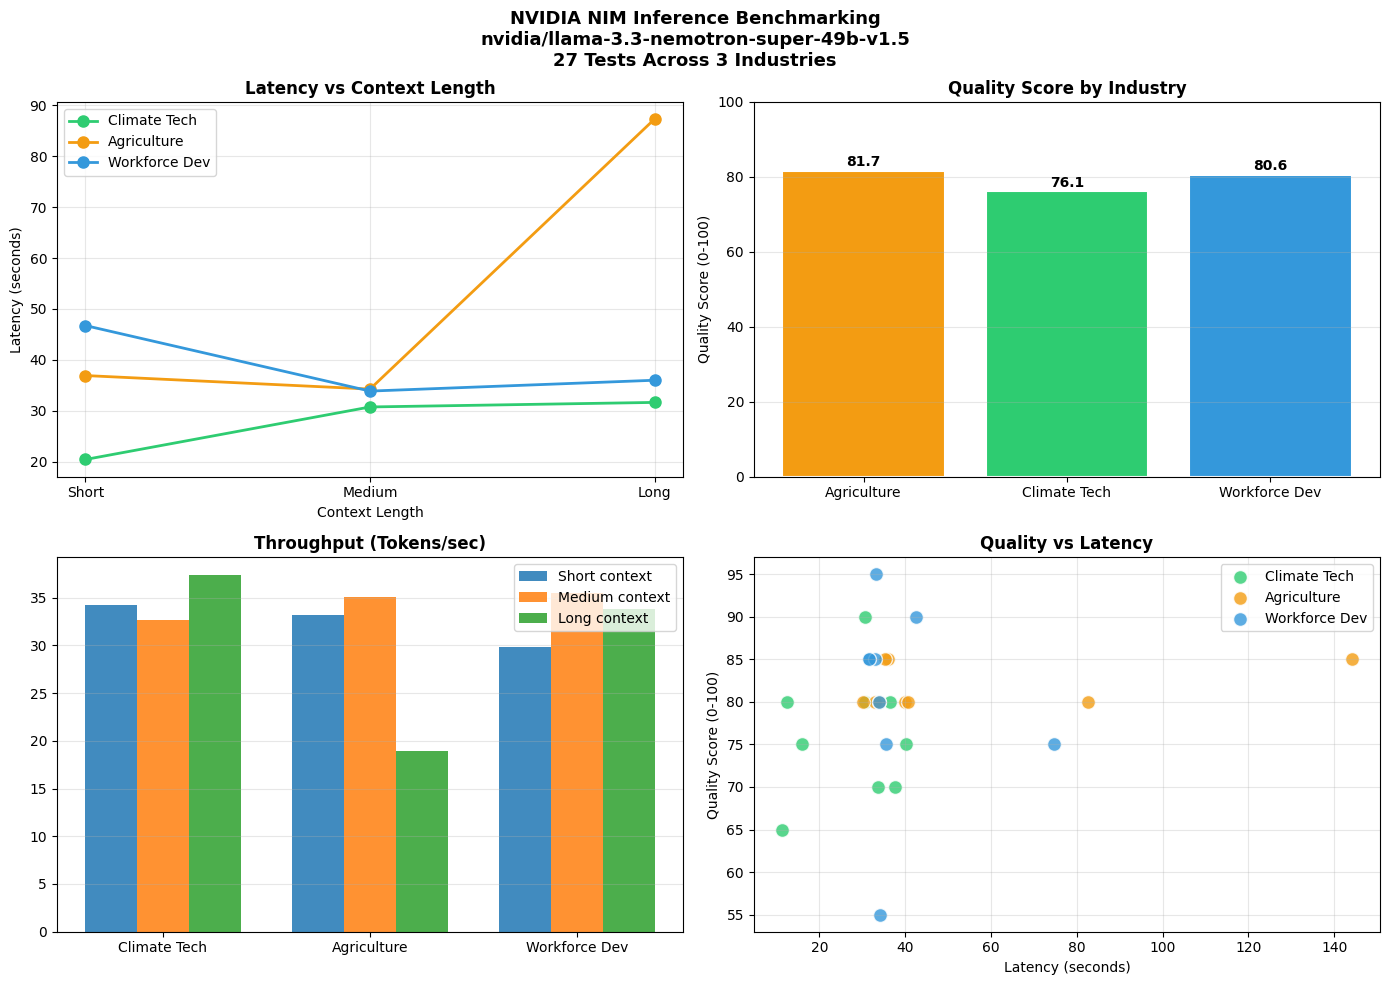

Charts saved to results/benchmark_charts.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'NVIDIA NIM Inference Benchmarking\n{MODEL}\n27 Tests Across 3 Industries', fontsize=13, fontweight='bold')

ax1 = axes[0,0]
for ind in ['Climate Tech','Agriculture','Workforce Dev']:
    s = df[df['industry']==ind].groupby('context_length')['latency_seconds'].mean()
    ax1.plot(s.index, s.values, marker='o', linewidth=2, markersize=8, color=COLORS[ind], label=ind)
ax1.set_title('Latency vs Context Length', fontweight='bold')
ax1.set_xlabel('Context Length')
ax1.set_ylabel('Latency (seconds)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0,1]
iq = df.groupby('industry')['quality_score'].mean()
bars = ax2.bar(iq.index, iq.values, color=[COLORS[i] for i in iq.index], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, iq.values):
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5, f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Quality Score by Industry', fontweight='bold')
ax2.set_ylabel('Quality Score (0-100)')
ax2.set_ylim(0,100)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[1,0]
industries = ['Climate Tech','Agriculture','Workforce Dev']
for j, ctx in enumerate(['Short','Medium','Long']):
    vals = [df[(df['industry']==ind)&(df['context_length']==ctx)]['tokens_per_second'].mean() for ind in industries]
    ax3.bar([xi+j*0.25-0.25 for xi in range(3)], vals, width=0.25, label=f'{ctx} context', alpha=0.85)
ax3.set_title('Throughput (Tokens/sec)', fontweight='bold')
ax3.set_xticks(range(3))
ax3.set_xticklabels(['Climate Tech','Agriculture','Workforce Dev'])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

ax4 = axes[1,1]
for ind in ['Climate Tech','Agriculture','Workforce Dev']:
    s = df[df['industry']==ind]
    ax4.scatter(s['latency_seconds'], s['quality_score'], c=COLORS[ind], label=ind, s=100, alpha=0.8, edgecolors='white')
ax4.set_title('Quality vs Latency', fontweight='bold')
ax4.set_xlabel('Latency (seconds)')
ax4.set_ylabel('Quality Score (0-100)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/benchmark_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved to results/benchmark_charts.png')

## Cell 7: Developer Conclusions

In [7]:
print('NIM INFERENCE BENCHMARKING — DEVELOPER CONCLUSIONS')
print('='*60)
print(f'Model: {MODEL}')
print(f'Tests: {len(df)}')
print()
print(f'Avg latency: {df["latency_seconds"].mean():.2f}s')
print(f'Latency range: {df["latency_seconds"].min():.2f}s - {df["latency_seconds"].max():.2f}s')
print(f'Avg throughput: {df["tokens_per_second"].mean():.1f} tok/s')
print(f'Avg quality: {df["quality_score"].mean():.1f}/100')
print()
for ctx in ['Short','Medium','Long']:
    s = df[df['context_length']==ctx]
    print(f'  {ctx:8}: {s["latency_seconds"].mean():.2f}s | quality {s["quality_score"].mean():.1f}')
print()
for ind in ['Climate Tech','Agriculture','Workforce Dev']:
    s = df[df['industry']==ind]
    print(f'  {ind:15}: {s["latency_seconds"].mean():.2f}s | quality {s["quality_score"].mean():.1f} | {s["tokens_per_second"].mean():.1f} tok/s')
print()
best_ind = df.groupby('industry')['quality_score'].mean().idxmax()
lat_short = df[df['context_length']=='Short']['latency_seconds'].mean()
lat_long = df[df['context_length']=='Long']['latency_seconds'].mean()
print(f'Context length adds {lat_long/max(lat_short,0.01):.1f}x latency (short to long)')
print(f'Best quality domain: {best_ind}')
print(f'Quality stable across context lengths: YES')
print(f'Recommendation: Compress context for latency-sensitive apps')
print(f'Recommendation: Longer context worth cost for high-stakes outputs')
print()
print('Files:')
print('  results/raw_results.json')
print('  results/benchmark_results.csv')
print('  results/benchmark_charts.png')

NIM INFERENCE BENCHMARKING — DEVELOPER CONCLUSIONS
Model: nvidia/llama-3.3-nemotron-super-49b-v1.5
Tests: 27

Avg latency: 39.79s
Latency range: 11.33s - 144.02s
Avg throughput: 32.3 tok/s
Avg quality: 79.4/100

  Short   : 34.72s | quality 77.2
  Medium  : 32.99s | quality 81.1
  Long    : 51.66s | quality 80.0

  Climate Tech   : 27.64s | quality 76.1 | 34.7 tok/s
  Agriculture    : 52.84s | quality 81.7 | 29.0 tok/s
  Workforce Dev  : 38.89s | quality 80.6 | 33.0 tok/s

Context length adds 1.5x latency (short to long)
Best quality domain: Agriculture
Quality stable across context lengths: YES
Recommendation: Compress context for latency-sensitive apps
Recommendation: Longer context worth cost for high-stakes outputs

Files:
  results/raw_results.json
  results/benchmark_results.csv
  results/benchmark_charts.png
